Loaded dataset: Droidware.csv | shape=(20000, 154)
Selected features (combined score > 0.4): 56 / 153
Outputs saved to: C:\Users\Arvind\Droidware\entropy_diversity_outputs_gt0p4_plots


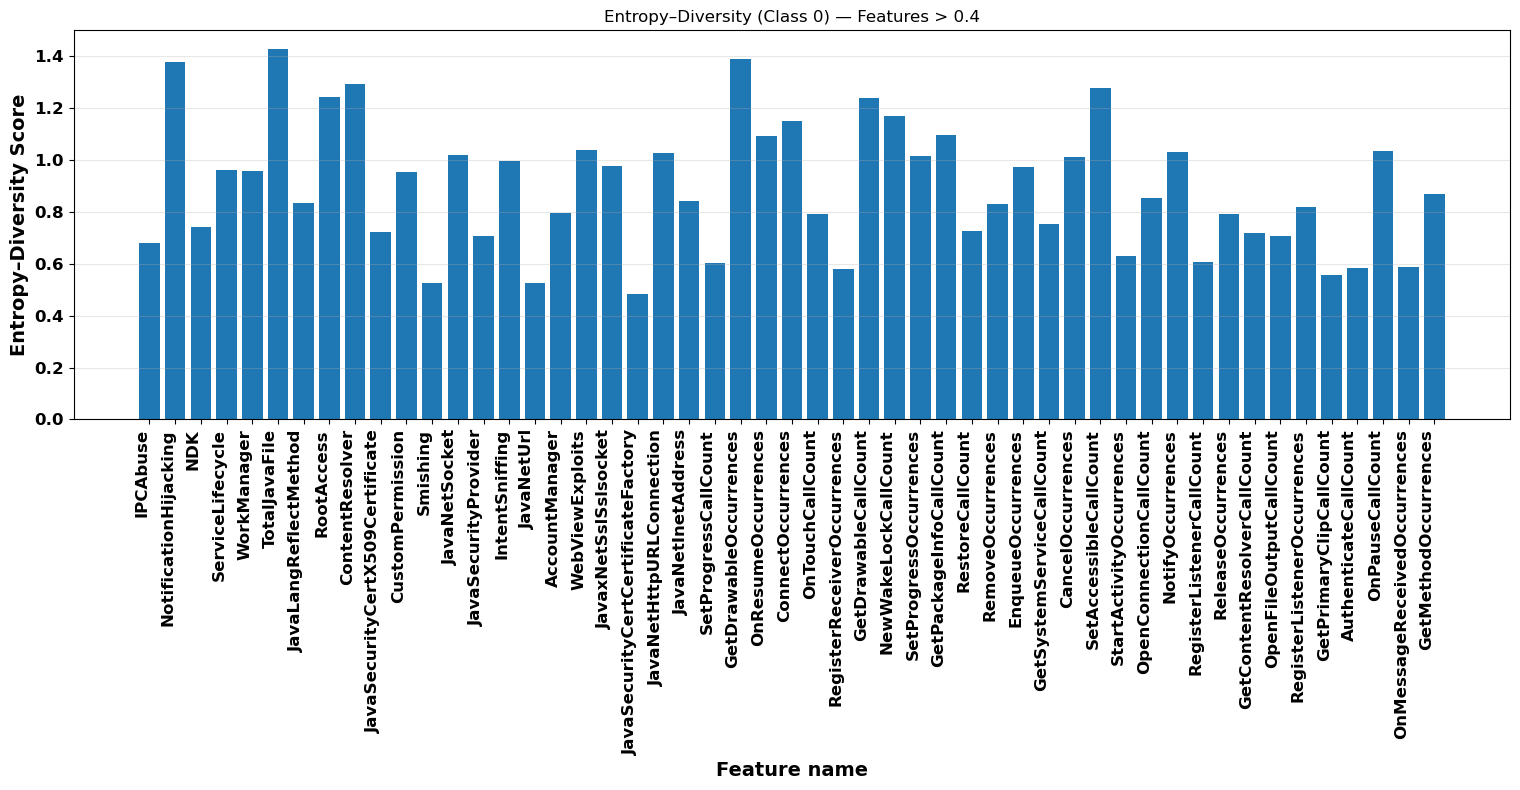

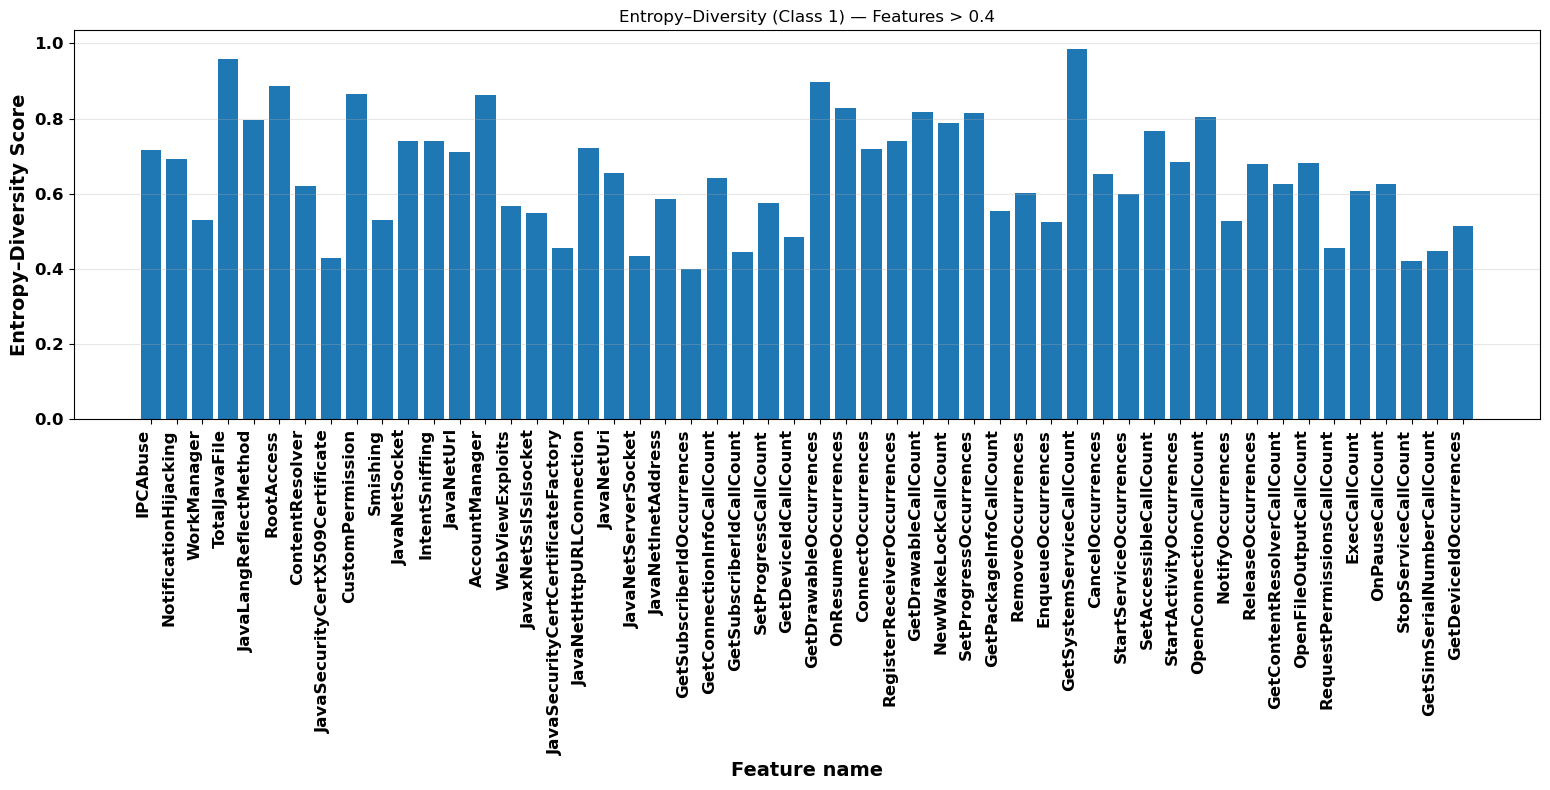

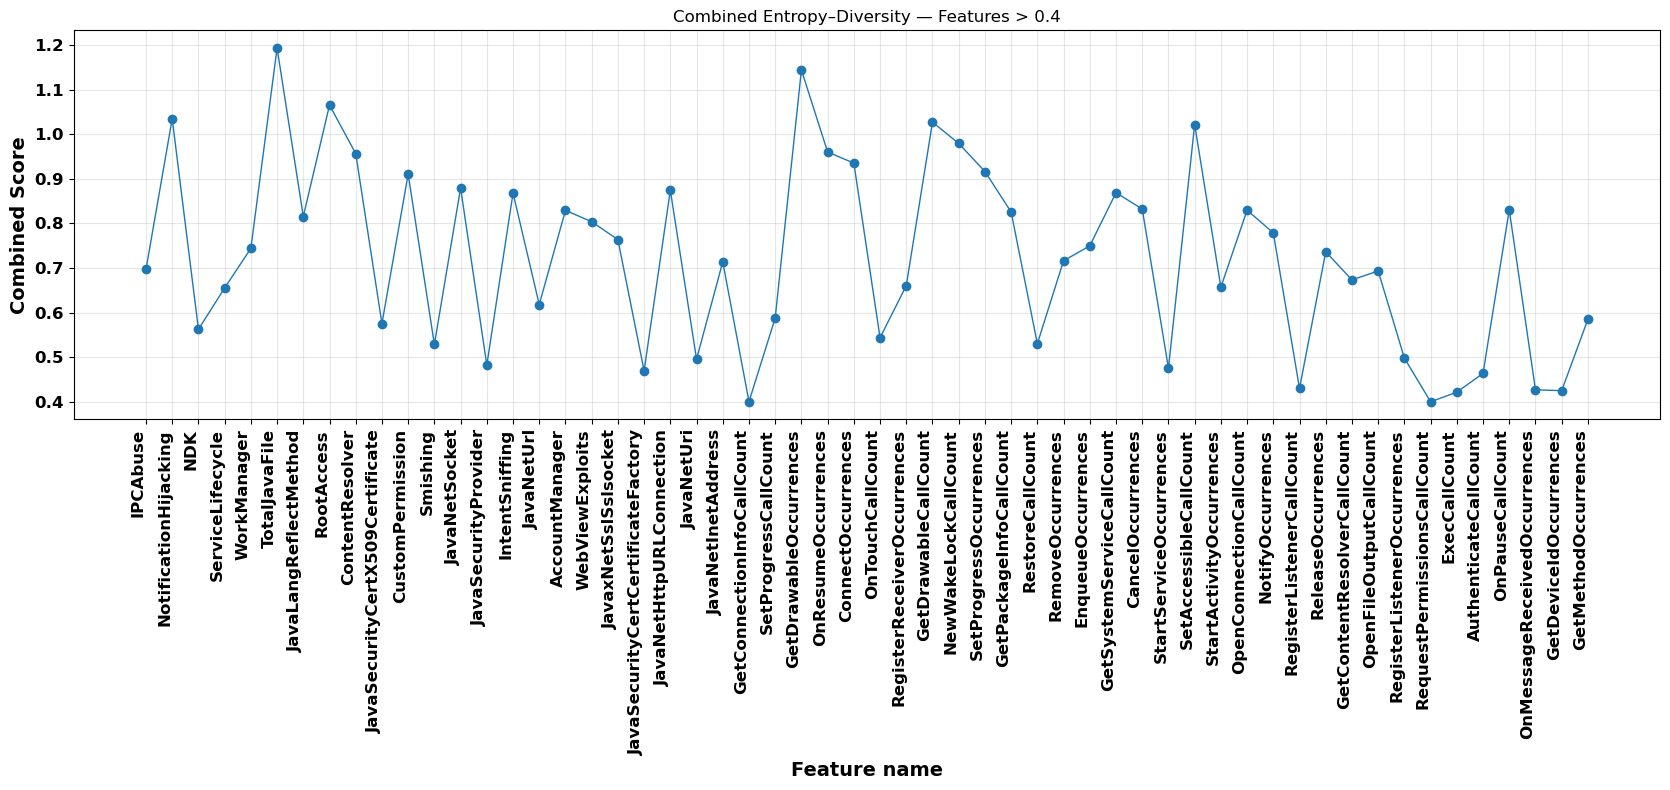


=== Selected features (score > 0.4) ===
IPCAbuse
NotificationHijacking
NDK
ServiceLifecycle
WorkManager
TotalJavaFile
JavaLangReflectMethod
RootAccess
ContentResolver
JavaSecurityCertX509Certificate
CustomPermission
Smishing
JavaNetSocket
JavaSecurityProvider
IntentSniffing
JavaNetUrl
AccountManager
WebViewExploits
JavaxNetSslSslsocket
JavaSecurityCertCertificateFactory
JavaNetHttpURLConnection
JavaNetUri
JavaNetInetAddress
GetConnectionInfoCallCount
SetProgressCallCount
GetDrawableOccurrences
OnResumeOccurrences
ConnectOccurrences
OnTouchCallCount
RegisterReceiverOccurrences
GetDrawableCallCount
NewWakeLockCallCount
SetProgressOccurrences
GetPackageInfoCallCount
RestoreCallCount
RemoveOccurrences
EnqueueOccurrences
GetSystemServiceCallCount
CancelOccurrences
StartServiceOccurrences
SetAccessibleCallCount
StartActivityOccurrences
OpenConnectionCallCount
NotifyOccurrences
RegisterListenerCallCount
ReleaseOccurrences
GetContentResolverCallCount
OpenFileOutputCallCount
RegisterListenerOc

In [16]:
"""
Entropy–Diversity Analysis (plots only features with score > 0.4)
-----------------------------------------------------------------
1) Load 'Droidware.csv' (last column = Label)
2) Compute per-class entropy & diversity per feature
   - Entropy: Shannon entropy of standardized values' histogram
   - Diversity: unique value ratio
   - Score = (entropy + diversity) / 2
3) Combine class scores (mean per feature)
4) Filter and plot only features with score > 0.4
5) Save CSVs and feature names.
"""

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import entropy
import matplotlib.pyplot as plt

# ---------------------
# CONFIG
# ---------------------
CSV_CANDIDATES = ["Droidware.csv", "droidware.csv", "/mnt/data/Droidware.csv"]
SAMPLE_ROWS = 20000
BINS = 30
SCORE_THRESHOLD = 0.4
ROTATION = 90
FONTSIZE = 12
FIG_HEIGHT = 8
OUT_DIR = Path("entropy_diversity_outputs_gt0p4_plots")
OUT_DIR.mkdir(exist_ok=True)

# ---------------------
# LOAD CSV (memory-safe)
# ---------------------
csv_path = next((p for p in CSV_CANDIDATES if Path(p).exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find 'Droidware.csv'.")

if SAMPLE_ROWS:
    df_iter = pd.read_csv(csv_path, chunksize=SAMPLE_ROWS)
    df = next(df_iter)
else:
    df = pd.read_csv(csv_path)

print(f"Loaded dataset: {csv_path} | shape={df.shape}")

label_col = df.columns[-1]
X = df.iloc[:, :-1].copy()
y = df[label_col].copy().values

# ---------------------
# PREPROCESS
# ---------------------
X = X.apply(pd.to_numeric, errors="coerce")
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_imp), columns=X.columns)

classes = np.unique(y)
if len(classes) < 2:
    raise ValueError("Expected at least two distinct label classes.")
class_subsets = {cls: X_scaled[y == cls] for cls in classes}

# ---------------------
# ENTROPY–DIVERSITY FUNCTION
# ---------------------
def entropy_diversity_scores(X_sub, bins=BINS):
    ent, div = [], []
    for col in X_sub.columns:
        vals = X_sub[col].values
        hist, _ = np.histogram(vals, bins=bins, density=True)
        hist = hist[hist > 0]
        H = entropy(hist) if hist.size > 0 else 0.0
        D = len(np.unique(vals)) / len(vals) if len(vals) else 0.0
        ent.append(H)
        div.append(D)
    out = pd.DataFrame({
        "feature": X_sub.columns,
        "entropy": ent,
        "diversity": div
    })
    out["score"] = (out["entropy"] + out["diversity"]) / 2.0
    return out

# Compute per-class scores
scores_by_class = {cls: entropy_diversity_scores(class_subsets[cls]) for cls in classes}

# ---------------------
# COMBINE SCORES
# ---------------------
combined = pd.DataFrame({"feature": X_scaled.columns})
for cls in classes:
    combined[f"score_{cls}"] = combined["feature"].map(
        scores_by_class[cls].set_index("feature")["score"]
    )
combined["combined_score"] = combined[[f"score_{cls}" for cls in classes]].mean(axis=1)

# ---------------------
# FILTER (score > 0.4)
# ---------------------
combined_filtered = combined[combined["combined_score"] > SCORE_THRESHOLD]
scores_filtered = {cls: df[df["score"] > SCORE_THRESHOLD] for cls, df in scores_by_class.items()}

# Save outputs
combined_filtered.to_csv(OUT_DIR / "combined_filtered_gt0p4.csv", index=False)
for cls, df in scores_filtered.items():
    df.to_csv(OUT_DIR / f"class_{cls}_filtered_gt0p4.csv", index=False)
combined_filtered["feature"].to_csv(OUT_DIR / "selected_features_gt0p4.txt", index=False, header=False)

print(f"Selected features (combined score > {SCORE_THRESHOLD}): {len(combined_filtered)} / {len(combined)}")
print(f"Outputs saved to: {OUT_DIR.resolve()}")

# ---------------------
# PLOT HELPERS
# ---------------------
def figure_width(n_features, min_width=12, per_label=0.3):
    """Scale figure width to accommodate feature labels."""
    return max(min_width, n_features * per_label)

def plot_class(scores_df, cls_label, save_name):
    n = len(scores_df)
    if n == 0:
        print(f"No features > {SCORE_THRESHOLD} for class {cls_label}.")
        return
    plt.figure(figsize=(figure_width(n), FIG_HEIGHT))
    plt.bar(scores_df["feature"], scores_df["score"], width=0.8)
    plt.title(f"Entropy–Diversity (Class {cls_label}) — Features > {SCORE_THRESHOLD}")
    plt.xlabel("Feature name", fontsize=FONTSIZE+2, fontweight='bold')
    plt.ylabel("Entropy–Diversity Score", fontsize=FONTSIZE+2, fontweight='bold')
    plt.xticks(rotation=ROTATION, ha='right', fontsize=FONTSIZE, fontweight='bold')
    plt.yticks(fontsize=FONTSIZE, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / save_name, dpi=300)
    plt.show()

def plot_combined(combined_df, save_name):
    n = len(combined_df)
    if n == 0:
        print("No combined features above threshold.")
        return
    plt.figure(figsize=(figure_width(n), FIG_HEIGHT))
    plt.plot(combined_df["feature"], combined_df["combined_score"], marker='o', linewidth=1)
    plt.title(f"Combined Entropy–Diversity — Features > {SCORE_THRESHOLD}")
    plt.xlabel("Feature name", fontsize=FONTSIZE+2, fontweight='bold')
    plt.ylabel("Combined Score", fontsize=FONTSIZE+2, fontweight='bold')
    plt.xticks(rotation=ROTATION, ha='right', fontsize=FONTSIZE, fontweight='bold')
    plt.yticks(fontsize=FONTSIZE, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / save_name, dpi=300)
    plt.show()

# ---------------------
# PLOTS (only features > 0.4)
# ---------------------
clsA = classes[0]
plot_class(scores_filtered[clsA], clsA, f"plot_class_{clsA}_gt0p4.png")

clsB = classes[1] if len(classes) > 1 else classes[0]
plot_class(scores_filtered[clsB], clsB, f"plot_class_{clsB}_gt0p4.png")

plot_combined(combined_filtered, "plot_combined_gt0p4.png")

# ---------------------
# PRINT FEATURE NAMES
# ---------------------
print("\n=== Selected features (score > 0.4) ===")
for f in combined_filtered["feature"]:
    print(f)
print(f"\nFeature list saved to: {OUT_DIR/'selected_features_gt0p4.txt'}")


In [16]:
cols = combined_filtered["feature"].tolist()
cols.append('Label')
df = pd.read_csv('Droidware.csv')
dfX = df[cols].copy()
#dfX.to_csv("DroidwareFSed.csv")
dfX.head(5)

,IPCAbuse,NotificationHijacking,NDK,ServiceLifecycle,WorkManager,TotalJavaFile,JavaLangReflectMethod,RootAccess,ContentResolver,JavaSecurityCertX509Certificate,...,OpenFileOutputCallCount,RegisterListenerOccurrences,RequestPermissionsCallCount,ExecCallCount,AuthenticateCallCount,OnPauseCallCount,OnMessageReceivedOccurrences,GetDeviceIdOccurrences,GetMethodOccurrences,Label
0,6,1315,33,5,24,1401,21,276,745,2,...,0,8,14,2,1,16,1,0,2,0
1,0,0,1,0,0,2,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
2,2,1150,49,7,35,3940,73,332,646,24,...,1,6,4,0,20,10,2,1,25,0
3,108,8340,39,2,0,5061,56,486,575,9,...,5,3,9,0,9,75,12,4,5,1
4,206,2687,60,8,74,6712,61,637,604,15,...,11,9,13,5,0,66,1,3,8,1


Original numeric, non-constant features: 56
Features kept (|corr| in [0.2, 0.8]): 56
Saved dendrogram to: dendrogram.png


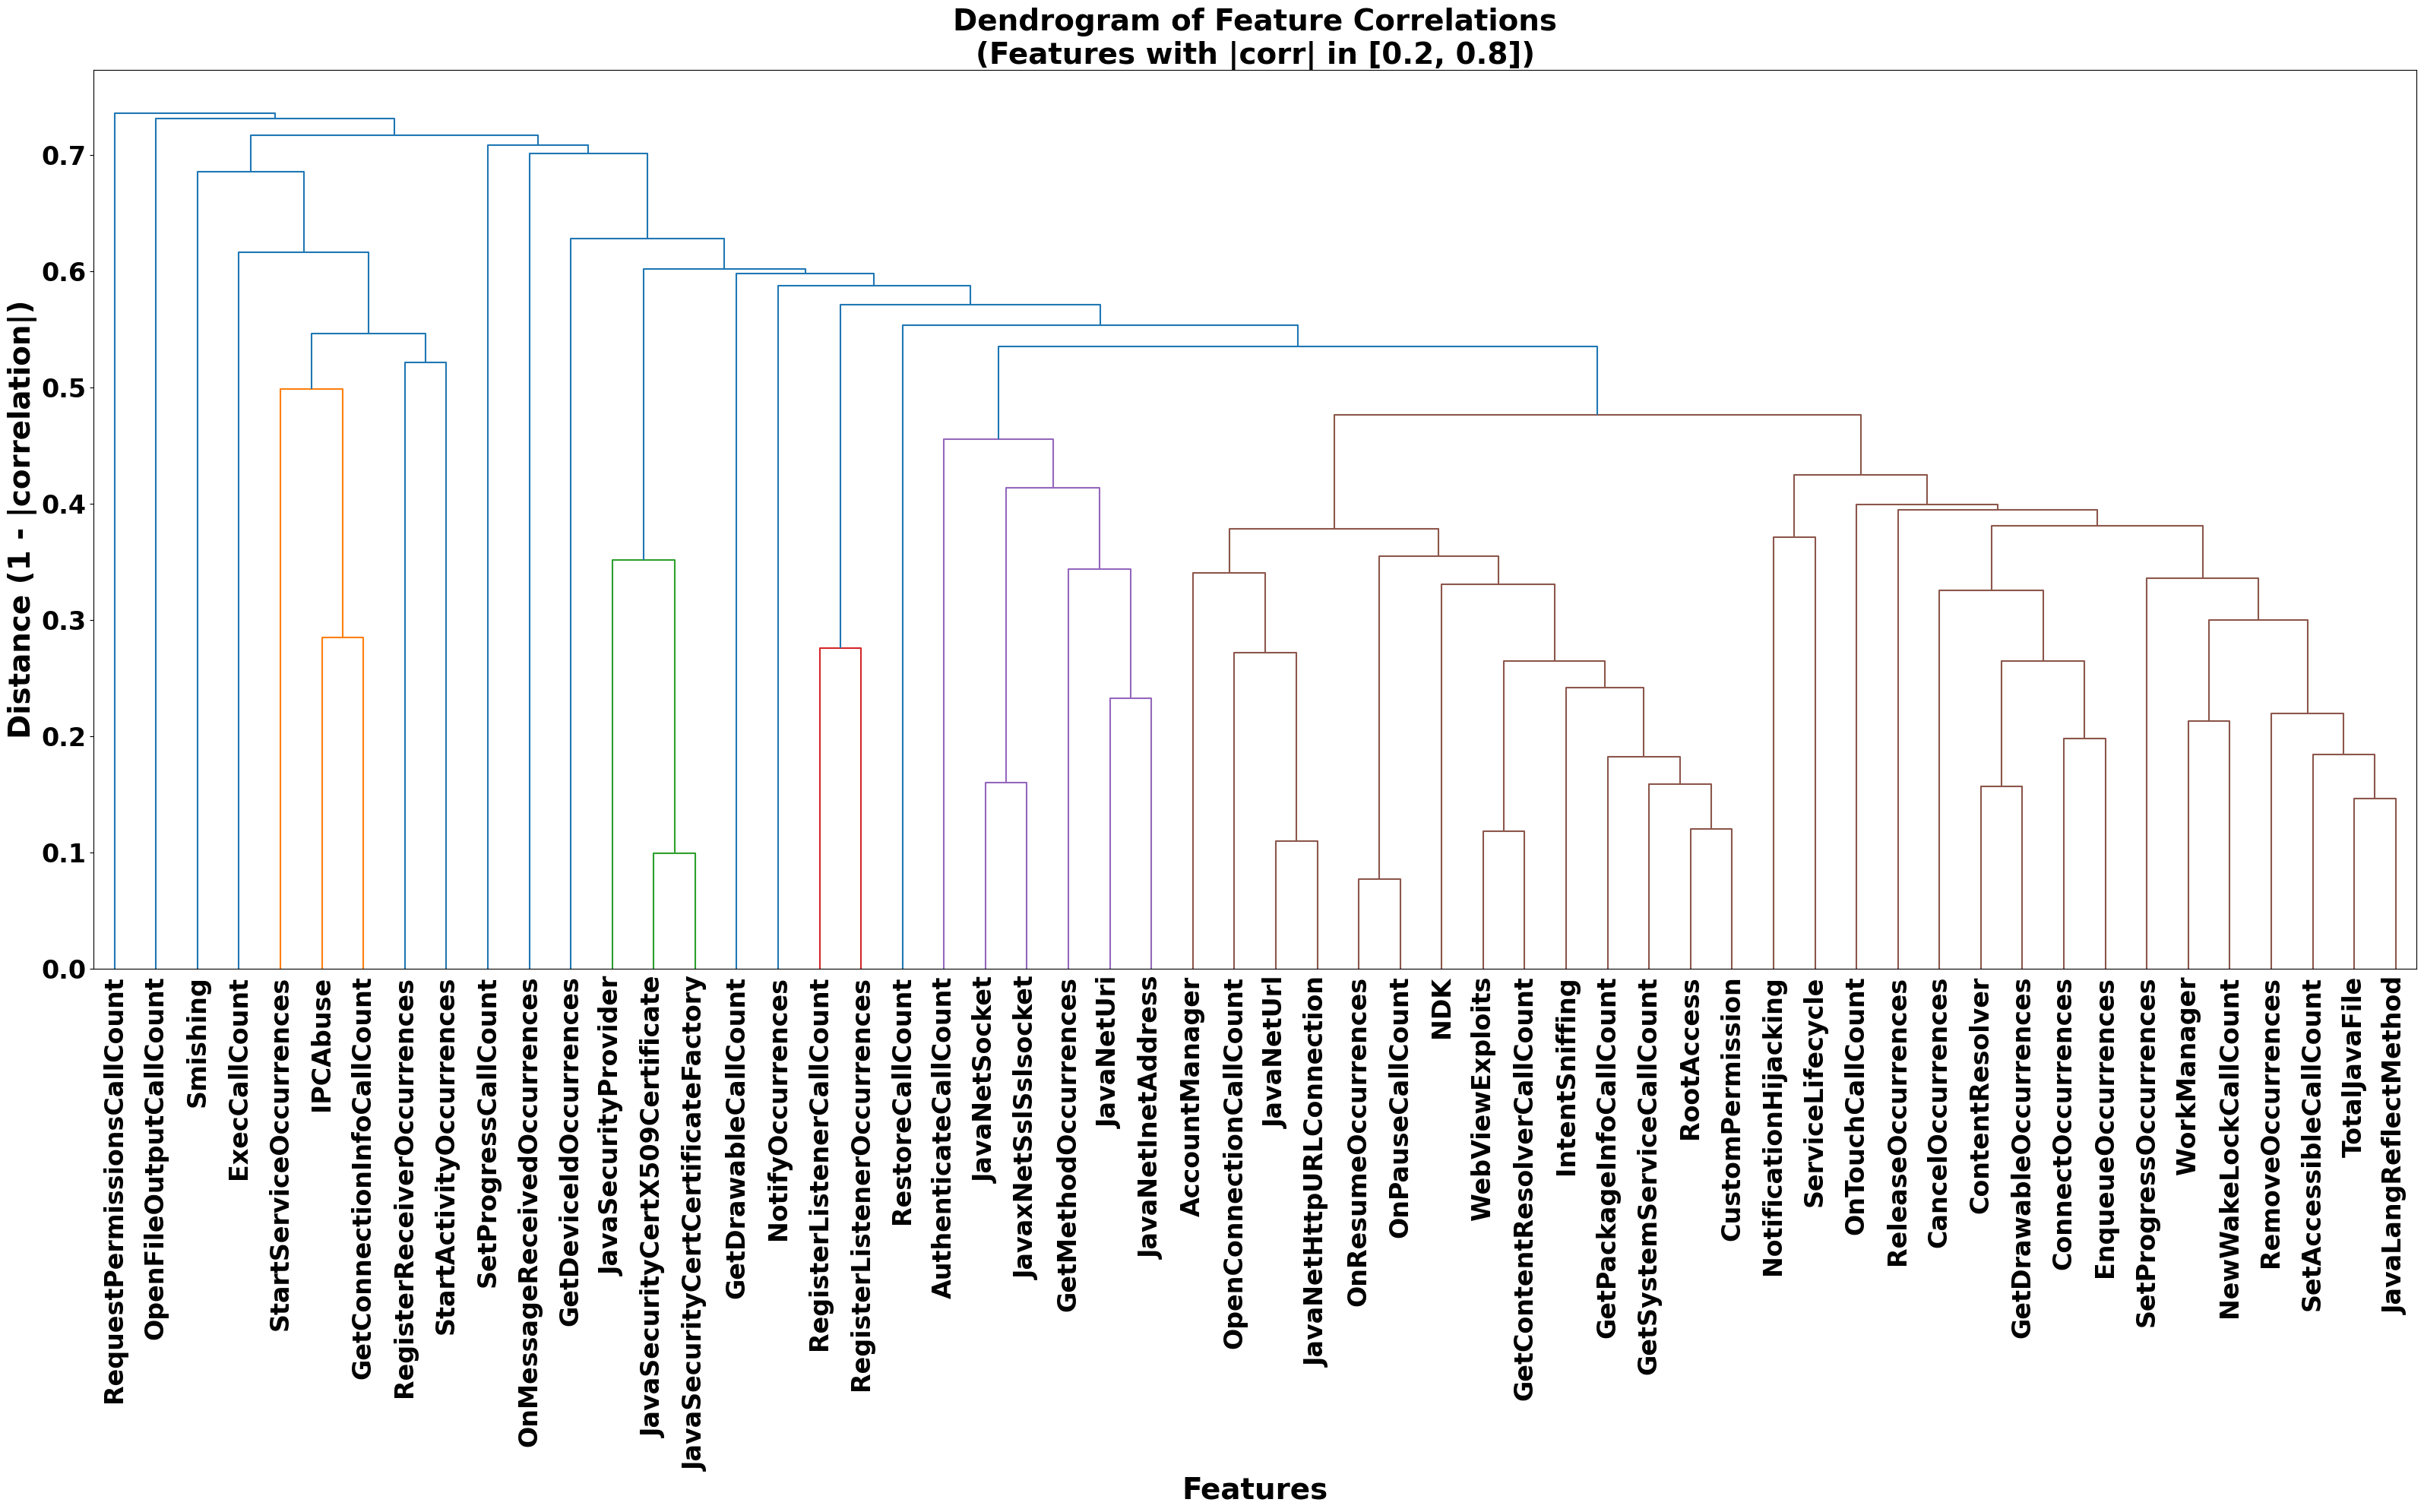

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

def correlation_dendrogram_from_csv(
    csv_path="DroidwareFSed.csv",
    min_correlation=0.2,
    max_correlation=0.8,
    fig_size=(32, 20),
    out_png="dendrogram.png"
):

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)
    df = df.iloc[:, :-1]

    # ---------- Keep only numeric, non-constant columns ----------
    numeric = df.select_dtypes(include=[np.number]).copy()
    if numeric.shape[1] == 0:
        raise ValueError("No numeric columns found in the dataset.")

    # drop constant (zero-variance) columns (corr would be NaN)
    variances = numeric.var(numeric_only=True)
    keep_cols = variances[variances > 0].index.tolist()
    if len(keep_cols) < 2:
        raise ValueError(
            "Fewer than two non-constant numeric columns remain; need at least 2."
        )
    numeric = numeric[keep_cols]

    # ---------- Correlation matrix ----------
    corr_matrix = numeric.corr(method="pearson")

    # ---------- Feature filtering by correlation window ----------
    # Keep features that have at least one *other* feature with |corr| in [min_correlation, max_correlation]
    features_to_keep = []
    for feature in corr_matrix.columns:
        vals = corr_matrix[feature].drop(labels=feature)  # exclude self corr=1
        has_valid = ((vals.abs() >= min_correlation) & (vals.abs() <= max_correlation)).any()
        if has_valid:
            features_to_keep.append(feature)
        else:
            print(f"Removing feature '{feature}': all |corr| < {min_correlation} OR > {max_correlation}")

    print(f"Original numeric, non-constant features: {corr_matrix.shape[0]}")
    print(f"Features kept (|corr| in [{min_correlation}, {max_correlation}]): {len(features_to_keep)}")

    # If too few features meet criteria, fall back to all
    if len(features_to_keep) < 2:
        print("Warning: Not enough features meet the criteria. Using all features instead.")
        features_to_keep = corr_matrix.columns.tolist()

    corr_filtered = corr_matrix.loc[features_to_keep, features_to_keep]

    # If still < 2 (edge case), abort early
    if corr_filtered.shape[0] < 2:
        raise ValueError("Need at least 2 features to build a dendrogram.")

    # ---------- Distance matrix for clustering ----------
    # Distance = 1 - |correlation|
    distance_matrix = 1.0 - np.abs(corr_filtered.values)

    # numerical safety: clip to [0, 1], zero diag, symmetry
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = np.clip((distance_matrix + distance_matrix.T) / 2.0, 0.0, 1.0)

    # condensed vector for linkage
    condensed = squareform(distance_matrix, checks=False)

    # ---------- Hierarchical clustering ----------
    Z = hierarchy.linkage(condensed, method="average")

    # ---------- Plot ----------
    plt.figure(figsize=fig_size)
    hierarchy.dendrogram(
        Z,
        labels=corr_filtered.columns.tolist(),
        orientation="top",
        leaf_rotation=90
    )

    ax = plt.gca()
    for line in ax.get_lines():
        line.set_linewidth(2.5)

    plt.title(
        f'Dendrogram of Feature Correlations\n(Features with |corr| in [{min_correlation}, {max_correlation}])',
        fontsize=28, fontweight='bold'
    )
    plt.xlabel('Features', fontsize=28, fontweight='bold')
    plt.ylabel('Distance (1 - |correlation|)', fontsize=28, fontweight='bold')
    plt.xticks(fontsize=24, fontweight='bold')
    plt.yticks(fontsize=24, fontweight='bold')
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Saved dendrogram to: {out_png}")

    plt.show()
    return corr_filtered


# ---- Run with your dataset and thresholds ----
if __name__ == "__main__":
    corr_filtered = correlation_dendrogram_from_csv(
        csv_path="DroidwareFSed.csv",
        min_correlation=0.2,
        max_correlation=0.8,
        fig_size=(32, 20),
        out_png="dendrogram.png"
    )
